## [CNN Autoencoder](https://www.digitalocean.com/community/tutorials/convolutional-autoencoder)

In [1]:
#!/home/ee577/miniconda3/envs/ee577/bin/python
# From https://www.digitalocean.com/community/tutorials/convolutional-autoencoder

import os
import sys
import torch
import requests
import numpy as np
import torchvision
import torch.nn as nn
from PIL import Image
from pathlib import Path
import torchvision.datasets as Datasets
import torchvision.transforms as transforms
from transformers import AutoImageProcessor, AutoModel

pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)

from src import *

# Load config file
config = global_config.config

#  configuring device
if torch.cuda.is_available():
    config.device = 'cuda:2' # use GPU #3
    print('Running on the GPU')
else:
    config.device = 'cpu'
    print('Running on the CPU')


2025-03-01 16:57:59.190915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740877079.202801 1497052 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740877079.206467 1497052 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-01 16:57:59.220330: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Running on the GPU


In [12]:
# Params for loading data
gen_params = {
    'data_dir': config.upenn_out_dir,
    'csv_dir': config.upenn_dir,
    'modality': ['mods'],
    'dim': (70,86,86),
    'n_channels': 4,
    'n_classes': 7,
    'seed': config.seed,
    'to_augment': False,
    'make_augment': False,
    'to_encode': False,
    'to_slice': True,
    'to_3D_slice': False,
    'n_slices': 1,
    'use_clinical': False,
    'augment_types': None,
    'batch_sz': 2,
}

#  generate training and testing dataloader
training_dl, validation_dl = datasets.load_upenn_2d_struct(gen_params)

#  select modality to train CNN
modality = 'T2' # choose from ['T2', 'FLAIR', 'T1', 'T1GD']
modality_id = helpers.modalities['struct'].index(modality)

#  extracting training and validation images
training_images = helpers.extract_images(training_dl, modality_id)
validation_images = helpers.extract_images(validation_dl, modality_id)

#  extracting test images for visualization purposes
test_images = validation_images[0:10]
    
#  creating pytorch datasets
training_data = datasets.CustomDataset(training_images, transforms=transforms.Compose([]))

validation_data = datasets.CustomDataset(validation_images, transforms=transforms.Compose([]))

test_data = datasets.CustomDataset(test_images, transforms=transforms.Compose([]))

for data in training_data:
    break


In [14]:
print(data.shape)
inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state
print(last_hidden_states.shape)


torch.Size([1, 86, 86])
torch.Size([1, 257, 768])


In [9]:

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)
print(torchvision.transforms.functional.pil_to_tensor(image).shape)

processor = AutoImageProcessor.from_pretrained('facebook/dinov2-base')
model = AutoModel.from_pretrained('facebook/dinov2-base')

inputs = processor(images=image, return_tensors="pt")
outputs = model(**inputs)
last_hidden_states = outputs.last_hidden_state
print(last_hidden_states.shape)


torch.Size([3, 480, 640])
torch.Size([1, 257, 768])


In [10]:

configuration = model.config
print(configuration)


Dinov2Config {
  "_attn_implementation_autoset": true,
  "_name_or_path": "facebook/dinov2-base",
  "apply_layernorm": true,
  "architectures": [
    "Dinov2Model"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 518,
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 14,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12"
  ],
  "torch_dtype": "float32",
  "transformers_version": "4.49.0",
  "use_mask_token": true,
  "use_swiglu_ffn": false
}

Encoder:
Sequential(
  (0): Conv2d(1, 8, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (3): ReLU()
  (4): Conv2d(8, 16, kernel_size=(1, 1), stride=(2, 2), padding=(1, 1))
  (5): ReLU()
  (6): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (7): ReLU()
  (8): Conv2d(16, 32, kernel_size=(1, 1), stride=(2, 2), padding=(1, 1))
  (9): ReLU()
  (10): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=23328, out_features=8000, bias=True)
  (14): ReLU()
  (15): Linear(in_features=8000, out_features=4000, bias=True)
  (16): ReLU()
  (17): Linear(in_features=4000, out_features=2000, bias=True)
  (18): ReLU()
)

Decoder:
Sequential(
  (0): Linear(in_features=2000, out_features=4000, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4000, out_features=8000, bias=True)
  (3): ReLU()
  (4): L

100%|██████████| 7/7 [00:00<00:00, 13.27it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 203.55it/s]


training_loss: 0.0324 validation_loss: 0.0384


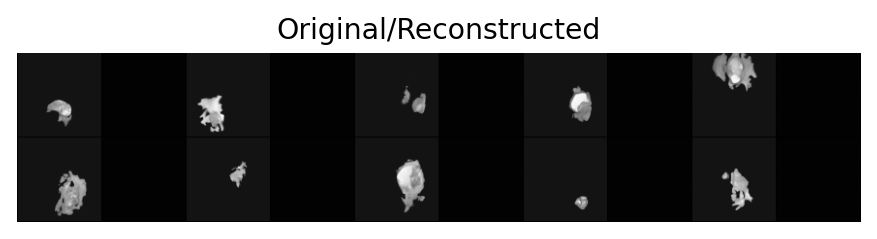

Epoch 2/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.69it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 257.01it/s]


training_loss: 0.0252 validation_loss: 0.0307


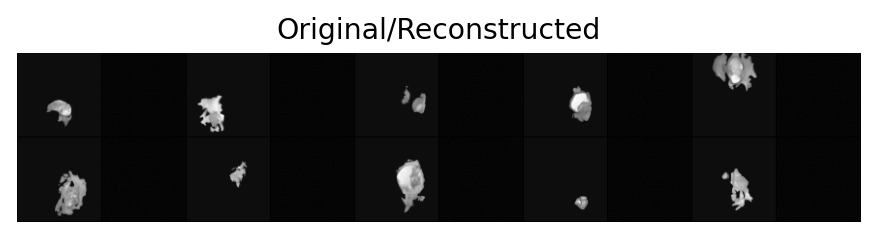

Epoch 3/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.70it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 260.58it/s]


training_loss: 0.0211 validation_loss: 0.0264


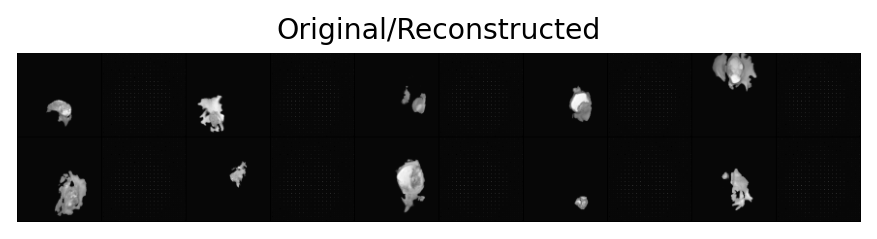

Epoch 4/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.68it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 258.49it/s]


training_loss: 0.0198 validation_loss: 0.0249


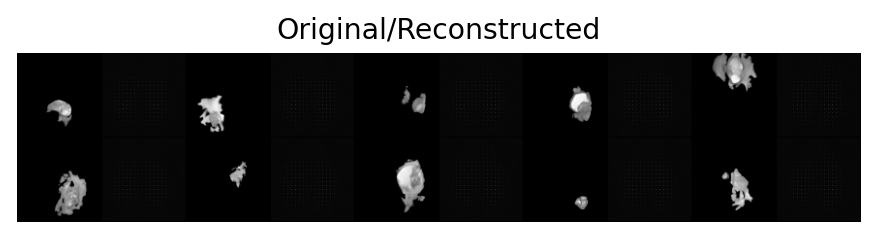

Epoch 5/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.69it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 261.12it/s]


training_loss: 0.0198 validation_loss: 0.0246


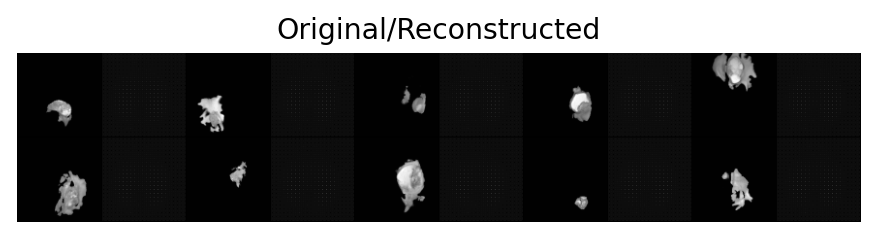

Epoch 6/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.81it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 261.63it/s]


training_loss: 0.02 validation_loss: 0.0246


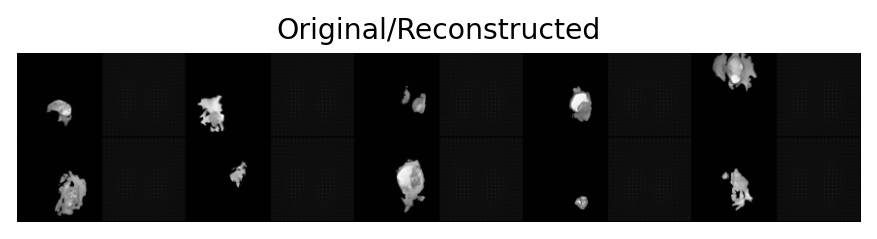

Epoch 7/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.82it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 262.93it/s]


training_loss: 0.02 validation_loss: 0.0246


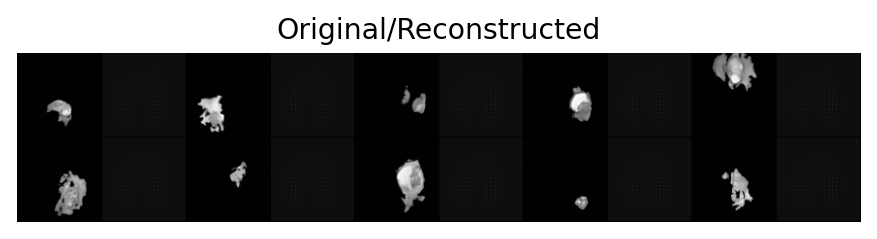

Epoch 8/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.75it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 262.04it/s]


training_loss: 0.0199 validation_loss: 0.0246


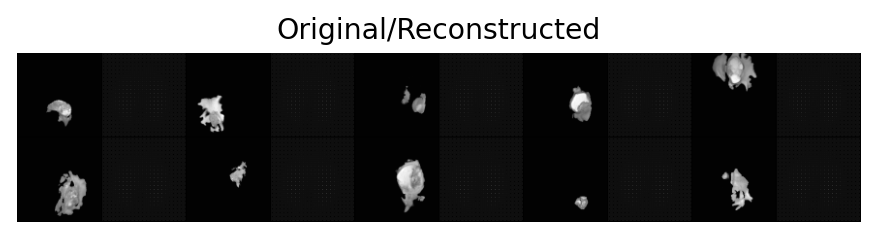

Epoch 9/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.71it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 231.63it/s]


training_loss: 0.0198 validation_loss: 0.0246


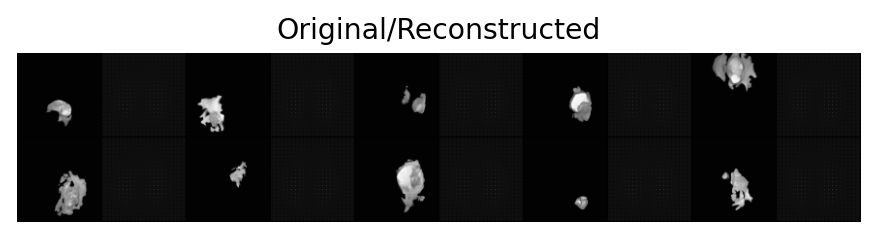

Epoch 10/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.84it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 257.30it/s]


training_loss: 0.0197 validation_loss: 0.0246


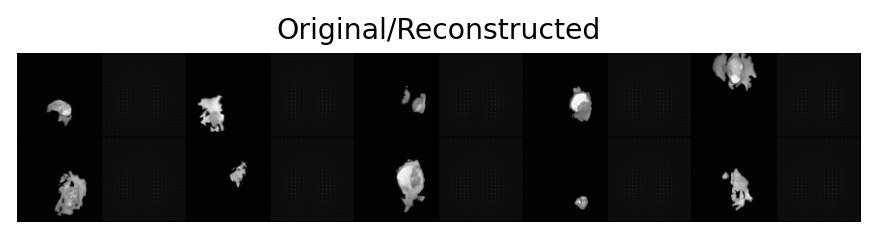

Epoch 11/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.81it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 262.81it/s]


training_loss: 0.0197 validation_loss: 0.0246


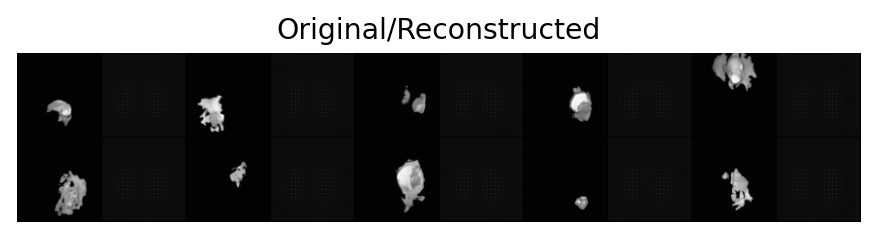

Epoch 12/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.86it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 261.64it/s]


training_loss: 0.0197 validation_loss: 0.0246


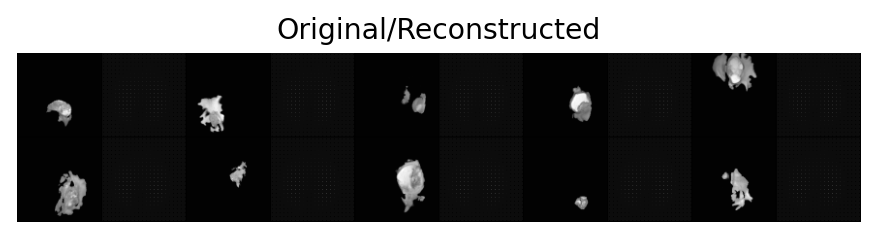

Epoch 13/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.88it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 261.80it/s]


training_loss: 0.0197 validation_loss: 0.0246


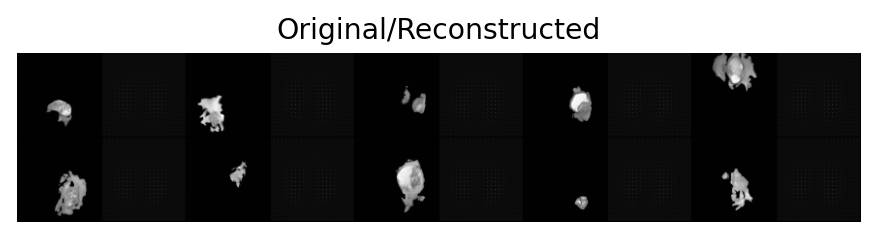

Epoch 14/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.88it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 261.64it/s]


training_loss: 0.0197 validation_loss: 0.0246


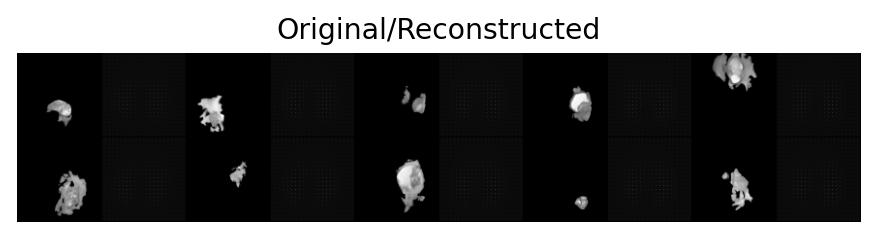

Epoch 15/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.76it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 256.84it/s]


training_loss: 0.0197 validation_loss: 0.0246


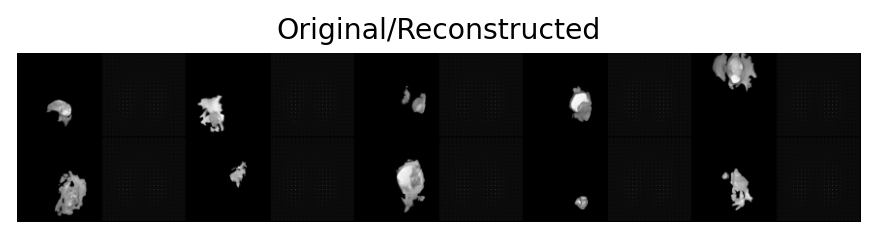

Epoch 16/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.60it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 259.06it/s]


training_loss: 0.0197 validation_loss: 0.0246


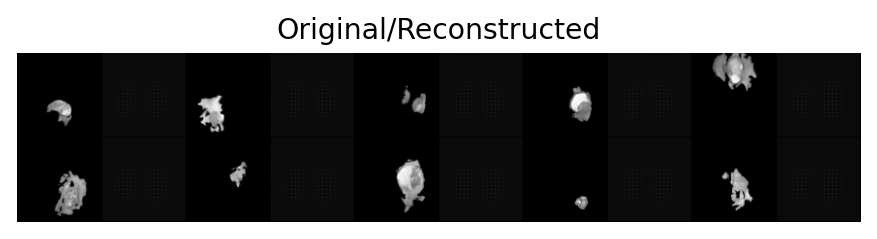

Epoch 17/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.83it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 238.60it/s]


training_loss: 0.0197 validation_loss: 0.0246


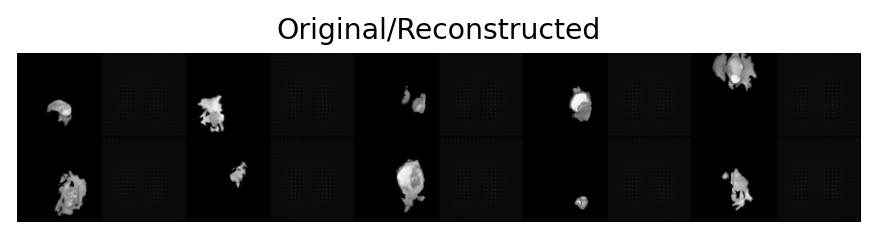

Epoch 18/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.82it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 265.23it/s]


training_loss: 0.0197 validation_loss: 0.0246


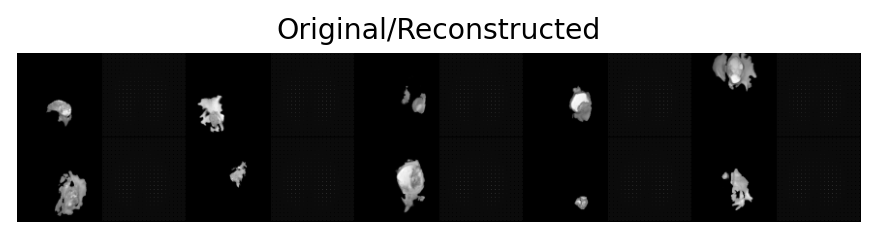

Epoch 19/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.76it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 260.61it/s]


training_loss: 0.0197 validation_loss: 0.0246


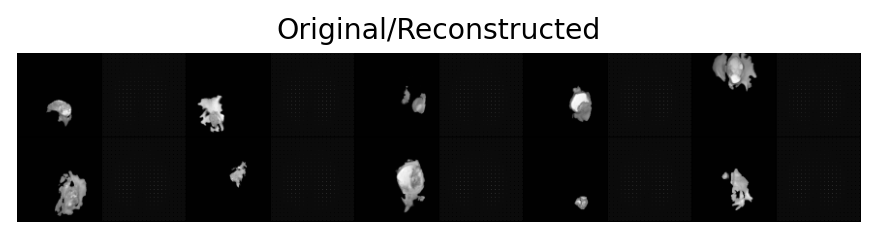

Epoch 20/20
training...


100%|██████████| 7/7 [00:00<00:00, 19.75it/s]


validating...


100%|██████████| 3/3 [00:00<00:00, 259.41it/s]


training_loss: 0.0197 validation_loss: 0.0246


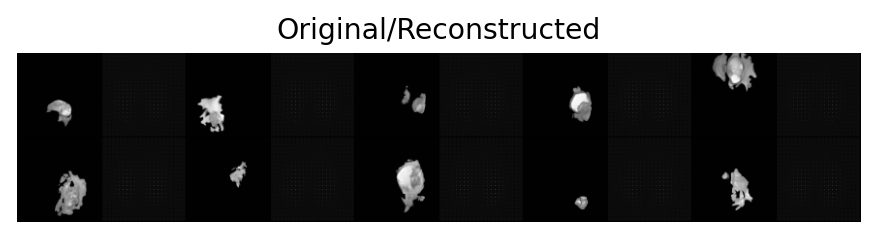

In [5]:

#  training model
model = models.ConvolutionalAutoencoder(models.UPENNAutoencoder(
    models.UPENNEncoder(in_channels=1,out_channels=8,img_len=86,latent_dim=2000),
    models.UPENNDecoder(in_channels=1,out_channels=8,img_len=86,latent_dim=2000)),
    in_channels=1,
    img_len = 86)

log_dict = model.train(nn.MSELoss(), epochs=20, batch_size=64, 
    training_set=training_data, validation_set=validation_data, test_set=test_data)


In [6]:


train_loss = np.asarray(log_dict['training_loss_per_batch'])
val_loss = np.asarray(log_dict['validation_loss_per_batch'])
num_batches = train_loss.shape[0]

plot_data.plot_line(np.arange(num_batches), train_loss, "train loss", 'Training loss per batch', 'batch number', 'training loss', save=True, fname="train_loss")
plot_data.plot_line(np.arange(num_batches), val_loss, "validation loss", 'validation loss per batch', 'batch number', 'validation loss', save=True, fname="val_loss")
